# YOLOv8 Installation

In [1]:
# Install YOLOv8
#%pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 59.6/112.6 GB disk)


# Tensorrt

In [2]:
#!pip install tensorrt

In [3]:
#!pip install tensorrt_lean

In [4]:
#!pip install tensorrt_dispatch

In [5]:
#!pip install onnx onnxsim onnxruntime-gpu

In [6]:
import tensorrt
print(tensorrt.__version__)
assert tensorrt.Builder(tensorrt.Logger())

11.0.0.114


In [7]:
#pip install torchvision==0.25

In [8]:
# Export YOLOv8 Model to Tensorrt
!yolo export model=yolov8x.pt format=engine half=True device=0

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs

PyTorch: starting from 'yolov8x.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (130.5 MB)

ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 9.5s, saved as 'yolov8x.onnx' (260.4 MB)

TensorRT: starting export with TensorRT 11.0.0.114...
[06/16/2026-06:20:20] [TRT] [I] [MemUsageChange] Init CUDA: CPU +0, GPU +0, now: CPU 1952, GPU 1014 (MiB)
TensorRT: converting ONNX to FP16 mixed precision with ModelOpt AutoCast...
2026-06-16 06:20:22,156 - [modelopt][onnx] - WARNING - Shared constants were detected and duplicated accordingly.
2026-06-16 06:20:24,483 - [modelopt][onnx] - INFO - Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']
2026-06-16 06:20:24,957 - [modelopt][onnx] - INFO - Running ONNX Runtime to obtain referenc

## Inference on Image

In [14]:
# Inference Using YOLOv8 Model
!yolo detect predict model=yolov8x.pt source="https://ultralytics.com/images/bus.jpg" device=0

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 80.9ms
Speed: 3.6ms preprocess, 80.9ms inference, 18.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-6
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [19]:
!yolo detect predict model=yolov8x.pt source="https://ultralytics.com/images/bus.jpg" half=True device=0

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 149.3ms
Speed: 3.2ms preprocess, 149.3ms inference, 17.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-9
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [16]:
# Inference Using YOLOv8 Tensorrt
!yolo detect predict model=yolov8x.engine source="https://ultralytics.com/images/bus.jpg" device=0

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading yolov8x.engine for TensorRT inference...
[06/16/2026-06:26:33] [TRT] [I] Loaded engine size: 132 MiB
[06/16/2026-06:26:34] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +87, now: CPU 0, GPU 219 (MiB)

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x640 4 persons, 1 bus, 28.2ms
Speed: 4.1ms preprocess, 28.2ms inference, 15.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-8
💡 Learn more at https://docs.ultralytics.com/modes/predict


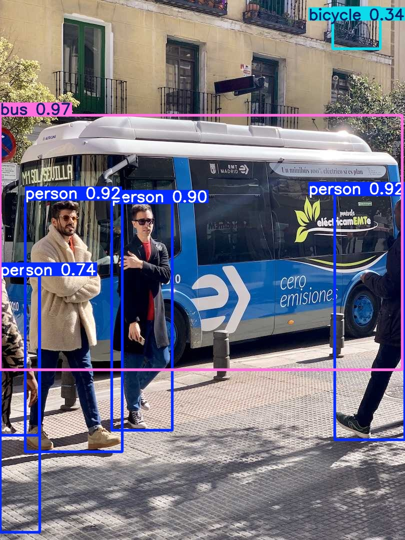

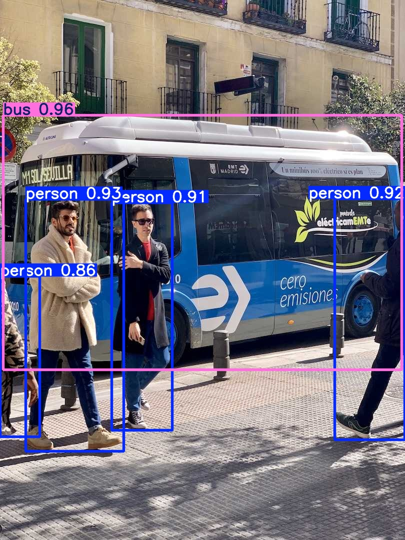

In [18]:
from PIL import Image
from IPython.display import display

# Load the images
image1 = Image.open("runs/detect/predict-7/bus.jpg")
image2 = Image.open("runs/detect/predict-8/bus.jpg")

w, h = image1.size
new_width = int(w/2)
new_height = int(h/2)

# Resize the images
image1 = image1.resize((new_width, new_height))
image2 = image2.resize((new_width, new_height))

# Display the images side by side
display(image1, image2)

## mAP

In [21]:
# mAP Calculation YOLOv8 Model
!yolo detect val model=yolov8x.pt data=coco128.yaml iou=0.5 imgsz=640 name=yolov8x verbose=False

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1677.4±527.1 MB/s, size: 37.9 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 24.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.0s
                   all        128        929      0.839      0.688      0.823      0.651
Speed: 4.0ms preprocess, 45.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/yolov8x-2
💡 Learn more at https://docs.ultralytics.com/modes/val


In [22]:
!yolo detect val model=yolov8x.pt data=coco128.yaml iou=0.5 imgsz=640 name=yolov8x half=True verbose=False

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2076.2±651.2 MB/s, size: 47.6 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 23.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.9it/s 4.2s
                   all        128        929      0.843      0.691      0.827      0.651
Speed: 1.7ms preprocess, 23.1ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/runs/detect/yolov8x-3
💡 Learn more at https://docs.ultralytics.com/modes/val


In [23]:
# mAP Calculation YOLOv8 Tensorrt
!yolo detect val model=yolov8x.engine data=coco128.yaml iou=0.5 imgsz=640 verbose=False name=yolov8x-tensorrt

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading yolov8x.engine for TensorRT inference...
[06/16/2026-06:32:32] [TRT] [I] Loaded engine size: 132 MiB
[06/16/2026-06:32:32] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +87, now: CPU 0, GPU 219 (MiB)
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1732.6±1279.1 MB/s, size: 53.0 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 21.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 41.7it/s 3.1s
                   all        128        929      0.836      0.692      0.819      0.647
Speed: 1.1ms preprocess, 15.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/yolov8x-tensorrt
💡 Learn more at https:

As we can see above reducing precison to half reduces the inference timings by approx 50% while maintaing the same level of accuracy.
Converting to tensorrt further brings down inference time while keeping accuracy almost at same level or pehaps loss of few fractions of accuracy